# Anomaly Detection in Mobile Networks

This notebook describes anomaly detection methods for drive test data.

**Target audience:** telecom engineers and PhD students  
**Dataset assumption:** `datasets/d2_Operator1_CapacityDL.csv`

## Learning objectives
<!-- 1. Load the raw dataset in a reproducible way.
2. Provide a consistent feature-naming convention.
3. Extract relevant features for network throughput analysis
4. Apply standard data cleaning techniques
5. Detect and mitigate multicollinearity
6. Perform advanced feature selection via correlation clustering
7. Summarize and visualize clean data -->


## Notebook flow
<!-- 1. Environment setup  
2. Load the raw dataset  
3. Standardize feature names
4. Manual selection of relevant variables for anomaly detection
5. Simple data preprocessing
6. Multicollinearity detection and removal
7. Correlation-based feature pruning via Gaussian mixtures and BIC
8. Statistical summary of the cleaned dataset -->

## 1. Environment Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from sklearn.covariance import EmpiricalCovariance, MinCovDet

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="talk")

## 2. Load the Raw Dataset

The dataset is read from the local `datasets/` directory.  A copy of the raw dataframe is preserved so the preprocessing logic remains auditable.

In [2]:
DATA_FILE = "data_clean"
DATA_PATH = Path("datasets") / f"{DATA_FILE}.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place the CSV in the expected folder or update DATA_PATH before running this notebook."
    )

data = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    sep=",",
    decimal=".",
    low_memory=False,
)

print(f"Cleaned dataset shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns")
display(data.head())

Cleaned dataset shape: 1,001 rows x 120 columns


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.b2a,throughput.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,fin.pkts.sent.a2b,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.50,abs.downlinkdelay.75,abs.downlinkdelay.max,abs.uplinkdelay.25,abs.uplinkdelay.50,abs.uplinkdelay.avg,abs.uplinkdelay.75,abs.uplinkdelay.max,abs.downlinkdeltadelay.25,abs.uplinkdeltadelay.avg,abs.rtt.min,abs.rtt.25,abs.rtt.50,abs.rtt.avg,abs.rtt.75,abs.rtt.max,abs.cwin.min,abs.cwin.25,abs.cwin.50,abs.cwin.avg,abs.cwin.75,abs.cwin.max,abs.rwin.25,abs.rwin.50,abs.rwin.75,abs.rwin.max,abs.winratio.min,abs.winratio.25,abs.winratio.50,abs.winratio.avg,abs.winratio.75,abs.winratio.max,abs.radiobuffer.min,abs.radiobuffer.25,abs.radiobuffer.50,abs.radiobuffer.avg,abs.radiobuffer.75,abs.radiobuffer.max,abs.idletime.50,abs.idletime.avg,abs.idletime.75,abs.idletime.max,abs.segmentsizes.min,abs.segmentsizes.25,abs.segmentsizes.50,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
0,100.0,24629.0,8.0,0.0,43.0,0.0,439348.0,17.0,65236.0,232.0,4.0,231.0,41937920.0,1946752.0,1638400.0,40000544.0,5.0,5.0,153524.0,5.0,24984.0,9.0,460.0,0.0,7.328,264.8,155.0,23.8,54.2,46.4,0.0,38.6,1.0,30.6,38.6,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,17.8,0.4,0.5,0.5,1.0,0.2,0.5,0.5,2.0,0.0,0.0,0.0,0.0,17621.0,2.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,41.0,3.0,38.0,54.0,334.0,8.0,10.0,8.460015,11.0,46.0,25.0,301.460015,0.0,38.0,48.0,55.818960,62.0,351.0,0.0,3167756.0,3475141.0,3.852855e+06,3913768.0,7352717.0,41937920.0,41937920.0,41937920.0,41937920.0,0.058522,0.076108,0.082864,0.096487,0.102346,0.292707,0.0,1606174.75,2148816.0,2.401342e+06,2784797.25,11976195.0,0.0,0.173705,0.0,252.0,1.0,2776.0,6940.0,65236.0,28.0,0.00008,14.0,3.0,3.983938e+09,3.131014e+13,448375.109
1,198.0,15636.0,42.0,0.0,22.0,0.0,72488.0,3190.0,55520.0,232.0,1.0,231.0,31455232.0,1599360.0,1638400.0,25549822.0,5.0,5.0,881001.0,3.0,19432.0,6.0,460.0,0.0,7.406,163.1,155.0,18.3,48.0,33.9,13.9,20.8,2.0,20.1,32.1,0.0,5.0,0.0,0.0,0.0,0.0,3.0,0.0,44.9,0.7,1.3,0.7,2.0,0.2,1.2,0.7,411.0,0.0,0.3,0.3,0.0,11922.0,62.0,1.0,0.0,170.2,34.04,0.0,5.0,0.0,2587.0,3.0,29.0,301.0,1727.0,1.0,11.0,-91.487522,14.0,200.0,12.0,1513.512478,1.0,27.0,42.0,135.827804,191.0,1741.0,0.0,1042825.0,1844469.0,3.130090e+06,3082700.0,10960755.0,21106688.0,31454208.0,31455232.0,31455232.0,0.013998,0.036512,0.059114,0.156073,0.209670,0.637286,0.0,438221.25,789585.5,1.207837e+06,1504034.50,9483651.0,0.0,0.315479,0.0,155.0,0.0,1388.0,2776.0,55520.0,397.0,0.00008,191.0,8.0,3.452638e+02,6.846370e+04,131054.310
2,5.0,25907.0,6.0,0.0,40.0,0.0,440036.0,951.0,65236.0,232.0,4.0,231.0,41943040.0,1365760.0,1638400.0,40072479.0,5.0,5.0,1084167.0,0.0,44416.0,10.0,460.0,0.0,7.351,191.0,155.0,12.7,20.5,18.4,0.0,20.5,1.0,16.3,20.5,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,44.2,0.5,1.9,0.6,1.0,0.3,0.6,0.6,521.0,0.0,0.0,0.0,0.0,22011.0,256.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,3114.0,3.0,37.0,54

## 3. Rule-based anomaly detection



          transfer.datarate  log10(transfer.datarate)
count             1001.0000                 1001.0000
mean            393434.7491                    5.5131
std             198472.1685                    0.3248
min               2408.9670                    3.3818
25%             253083.9300                    5.4033
50%             381348.1200                    5.5813
75%             519678.9110                    5.7157
max            1275028.0490                    6.1055
skewness             0.4792                   -2.2380
kurtosis             0.4115                    8.1728


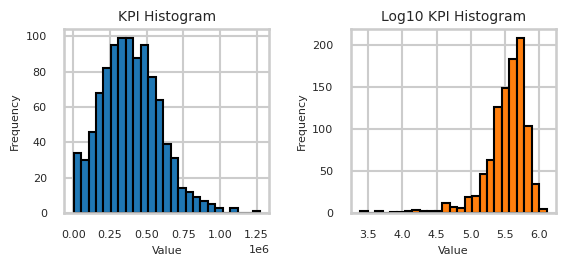

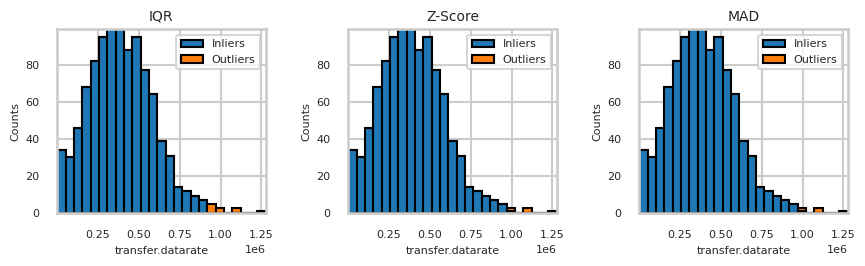

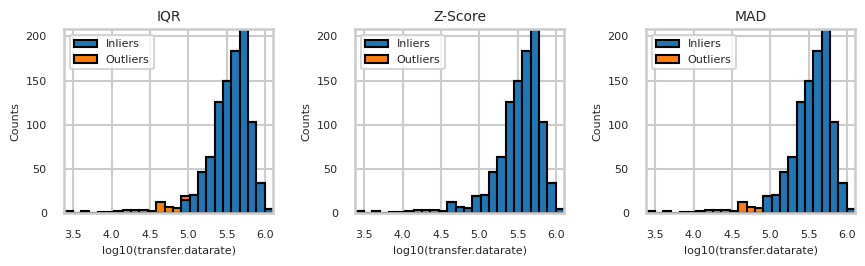

In [3]:
# -------------------------------------------------------------------
# KPI selection
# -------------------------------------------------------------------
target_kpi = 'transfer.datarate'
kpi_aux = data[target_kpi]
kpi_aux_log = np.log10(kpi_aux)


def stat_summary(s: pd.Series) -> pd.Series:
    q = s.quantile([0.25, 0.50, 0.75])
    return pd.Series(
        {
            "count": s.count(),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "25%": q.loc[0.25],
            "50%": q.loc[0.50],
            "75%": q.loc[0.75],
            "max": s.max(),
            "skewness": s.skew(),
            "kurtosis": s.kurtosis(),
        }
    )

summary = pd.concat(
    [
        stat_summary(kpi_aux).rename(target_kpi),
        stat_summary(kpi_aux_log).rename(f"log10({target_kpi})"),
    ],
    axis=1,
)
print(summary.to_string(float_format=lambda x: f"{x:.4f}"))

# -------------------------------------------------------------------
# Plot helpers
# -------------------------------------------------------------------
def format_axis(ax, xlabel, ylabel, title, tick_fs=8, label_fs=8, title_fs=8):
    ax.set_xlabel(xlabel, fontsize=label_fs)
    ax.set_ylabel(ylabel, fontsize=label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.xaxis.get_offset_text().set_fontsize(tick_fs)

def plot_distribution_pair(raw: pd.Series, log_s: pd.Series, bins: int = 25) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(6, 3), tight_layout=True)

    configs = [
        (raw.dropna(), "KPI Histogram", "Value", "Frequency", "tab:blue", 10, 8, 8),
        (log_s.dropna(), "Log10 KPI Histogram", "Value", "Frequency", "tab:orange", 10, 8, 8),
    ]
    for ax, (s, title, xlabel, ylabel, color, title_fs, label_fs, tick_fs) in zip(axes, configs):
        ax.hist(s, bins=bins, color=color, edgecolor="black")
        format_axis(ax, xlabel, ylabel, title, tick_fs=tick_fs, label_fs=label_fs, title_fs=title_fs)
    plt.show()


# -------------------------------------------------------------------
# Outlier rules
# -------------------------------------------------------------------
def detect_outliers_iqr(s: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s.lt(q1 - k * iqr) | s.gt(q3 + k * iqr)


def detect_outliers_zscore(s: pd.Series, threshold: float = 3.0) -> pd.Series:
    std = s.std()
    if pd.isna(std) or std == 0:
        return pd.Series(False, index=s.index)
    return ((s - s.mean()) / std).abs().gt(threshold)


def detect_outliers_mad(s: pd.Series, threshold: float = 3.0) -> pd.Series:
    median = s.median()
    mad = (s - median).abs().median()
    if pd.isna(mad) or mad == 0:
        return pd.Series(False, index=s.index)
    return (0.6745 * (s - median) / mad).abs().gt(threshold)


DETECTORS = {
    "IQR": detect_outliers_iqr,
    "Z-Score": detect_outliers_zscore,
    "MAD": detect_outliers_mad,
}


def plot_outlier_detection(s: pd.Series, xlabel: str, suffix: str = "", bins: int = 25) -> dict[str, pd.Series]:
    s = s.dropna()
    fig, axes = plt.subplots(1, 3, figsize=(9, 3), tight_layout=True)

    masks = {}
    for ax, (name, detector) in zip(axes, DETECTORS.items()):
        mask = detector(s)
        masks[name] = mask

        ax.hist(
            [s[~mask], s[mask]],
            bins=bins,
            stacked=True,
            color=["tab:blue", "tab:orange"],
            edgecolor="black",
            label=["Inliers", "Outliers"],
        )
        format_axis(
            ax,
            xlabel=xlabel,
            ylabel="Counts",
            title=f"{name}",
            tick_fs=8,
            label_fs=8,
            title_fs=10,
        )
        ax.legend(fontsize=8)
        ax.autoscale(axis="both", tight=True)

    plt.show()
    return masks

# -------------------------------------------------------------------
# Run plots
# -------------------------------------------------------------------
plot_distribution_pair(kpi_aux, kpi_aux_log)

outliers_kpi = plot_outlier_detection(kpi_aux, xlabel=target_kpi)
outliers_kpi_log = plot_outlier_detection(
    kpi_aux_log,
    xlabel=f"log10({target_kpi})",
    suffix=" (Log10 Transformed)",
)

## Anomaly Detection for Multivariable Data

### Robust Covariance (2D)

Estimated covariance matrix:
MCD (Robust):
[[ 3.60075119 -0.07640781]
 [-0.07640781  1.51855963]]
MLE:
[[ 3.23773583 -0.24640578]
 [-0.24640578  7.51963999]]


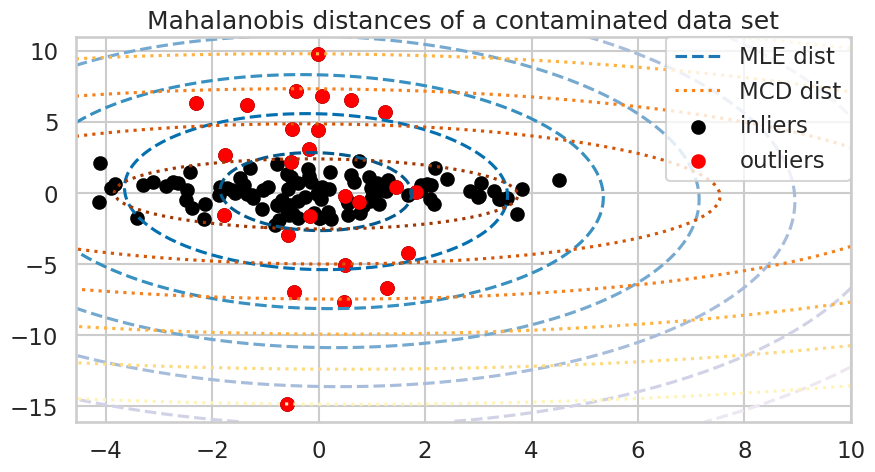

In [4]:
# for consistent results
np.random.seed(7)

n_samples = 125
n_outliers = 25
n_features = 2

# generate Gaussian data of shape (125, 2)
gen_cov = np.eye(n_features)
gen_cov[0, 0] = 2.0
X = np.dot(np.random.randn(n_samples, n_features), gen_cov)
# add some outliers
outliers_cov = np.eye(n_features)
outliers_cov[np.arange(1, n_features), np.arange(1, n_features)] = 7.0
X[-n_outliers:] = np.dot(np.random.randn(n_outliers, n_features), outliers_cov)

# fit a MCD robust estimator to data
robust_cov = MinCovDet().fit(X)
# fit a MLE estimator to data
emp_cov = EmpiricalCovariance().fit(X)
print(
    "Estimated covariance matrix:\nMCD (Robust):\n{}\nMLE:\n{}".format(
        robust_cov.covariance_, emp_cov.covariance_
    )
)


fig, ax = plt.subplots(figsize=(10, 5))
# Plot data set
inlier_plot = ax.scatter(X[:, 0], X[:, 1], color="black", label="inliers")
outlier_plot = ax.scatter(
    X[:, 0][-n_outliers:], X[:, 1][-n_outliers:], color="red", label="outliers"
)
ax.set_xlim(ax.get_xlim()[0], 10.0)
ax.set_title("Mahalanobis distances of a contaminated data set")

# Create meshgrid of feature 1 and feature 2 values
xx, yy = np.meshgrid(
    np.linspace(plt.xlim()[0], plt.xlim()[1], 100),
    np.linspace(plt.ylim()[0], plt.ylim()[1], 100),
)
zz = np.c_[xx.ravel(), yy.ravel()]
# Calculate the MLE based Mahalanobis distances of the meshgrid
mahal_emp_cov = emp_cov.mahalanobis(zz)
mahal_emp_cov = mahal_emp_cov.reshape(xx.shape)
emp_cov_contour = plt.contour(
    xx, yy, np.sqrt(mahal_emp_cov), cmap=plt.cm.PuBu_r, linestyles="dashed"
)
# Calculate the MCD based Mahalanobis distances
mahal_robust_cov = robust_cov.mahalanobis(zz)
mahal_robust_cov = mahal_robust_cov.reshape(xx.shape)
robust_contour = ax.contour(
    xx, yy, np.sqrt(mahal_robust_cov), cmap=plt.cm.YlOrBr_r, linestyles="dotted"
)

# Add legend
ax.legend(
    [
        mlines.Line2D([], [], color="tab:blue", linestyle="dashed"),
        mlines.Line2D([], [], color="tab:orange", linestyle="dotted"),
        inlier_plot,
        outlier_plot,
    ],
    ["MLE dist", "MCD dist", "inliers", "outliers"],
    loc="upper right",
    borderaxespad=0,
)

plt.show()